In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

sns.set(style="whitegrid")

In [2]:
BASE_PATH = Path(r"E:\Thesis")

HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

CHAR_DIR = BASE_PATH / "outputs" / "dataset_characterization"
MODEL_DIR = BASE_PATH / "outputs" / "densenet201_baseline"

OUT_DIR = BASE_PATH / "outputs" / "contrast_normalization_test"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_model.keras"

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]
IMG_SIZE = (250, 250)
BATCH_SIZE = 4

print("Model path:", MODEL_PATH)
print("Output folder:", OUT_DIR)

Model path: E:\Thesis\outputs\densenet201_baseline\best_model.keras
Output folder: E:\Thesis\outputs\contrast_normalization_test


In [3]:
summary = pd.read_csv(CHAR_DIR / "dataset_summary.csv")
print(summary[["dataset", "mean_contrast"]])

ham_mean_contrast = float(
    summary.loc[summary["dataset"] == "HAM10000", "mean_contrast"].iloc[0]
)
pad_mean_contrast = float(
    summary.loc[summary["dataset"] == "PAD_UFES_20", "mean_contrast"].iloc[0]
)

contrast_factor = ham_mean_contrast / pad_mean_contrast

print("HAM mean contrast:", ham_mean_contrast)
print("PAD mean contrast:", pad_mean_contrast)
print("Contrast scale factor:", contrast_factor)

       dataset  mean_contrast
0     HAM10000      28.426130
1  PAD_UFES_20      25.266878
HAM mean contrast: 28.42613021049315
PAD mean contrast: 25.26687759475512
Contrast scale factor: 1.1250353394039407


In [4]:
pad = pd.read_csv(PAD_PATH / "metadata.csv")

PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print(pad_4["exists"].value_counts())
print(pad_4["label"].value_counts())

exists
True    1871
Name: count, dtype: int64
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [5]:
def normalize_contrast_lab(image_path, out_path, factor):
    """
    Normalize contrast by scaling the L channel in LAB space.
    factor > 1 increases contrast
    factor < 1 decreases contrast
    """
    img = Image.open(image_path).convert("RGB")
    arr = np.array(img).astype(np.uint8)

    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:, :, 0]

    L_mean = L.mean()
    L_new = (L - L_mean) * factor + L_mean
    L_new = np.clip(L_new, 0, 255)

    lab[:, :, 0] = L_new
    rgb_out = cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2RGB)

    Image.fromarray(rgb_out).save(out_path)

In [6]:
NORMALIZED_DIR = OUT_DIR / "PAD_UFES_20_contrast_normalized_to_HAM"
NORMALIZED_DIR.mkdir(parents=True, exist_ok=True)

normalized_paths = []

for _, row in pad_4.iterrows():
    original_path = row["image_path"]
    filename = os.path.basename(original_path)
    out_path = NORMALIZED_DIR / filename

    if not out_path.exists():
        normalize_contrast_lab(
            image_path=original_path,
            out_path=out_path,
            factor=contrast_factor
        )

    normalized_paths.append(str(out_path))

pad_norm = pad_4.copy()
pad_norm["image_path"] = normalized_paths

print("Normalized images saved:", len(normalized_paths))
print(pad_norm[["img_id", "label", "image_path"]].head())

Normalized images saved: 1871
                  img_id label  \
0  PAT_1516_1765_530.png   NEV   
1     PAT_46_881_939.png   BCC   
2  PAT_1545_1867_547.png   ACK   
3  PAT_1989_4061_934.png   ACK   
4   PAT_684_1302_588.png   BCC   

                                          image_path  
0  E:\Thesis\outputs\contrast_normalization_test\...  
1  E:\Thesis\outputs\contrast_normalization_test\...  
2  E:\Thesis\outputs\contrast_normalization_test\...  
3  E:\Thesis\outputs\contrast_normalization_test\...  
4  E:\Thesis\outputs\contrast_normalization_test\...  


In [7]:
def luminance_contrast(path):
    img = Image.open(path).convert("RGB")
    arr = np.array(img).astype(np.float32)
    lum = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
    return float(lum.std())

sample_original = pad_4["image_path"].sample(5, random_state=42).tolist()
sample_norm = [str(NORMALIZED_DIR / os.path.basename(p)) for p in sample_original]

for o, n in zip(sample_original, sample_norm):
    print(
        os.path.basename(o),
        "original_contrast=", round(luminance_contrast(o), 2),
        "normalized_contrast=", round(luminance_contrast(n), 2)
    )

PAT_1571_2484_488.png original_contrast= 17.02 normalized_contrast= 19.2
PAT_567_1076_545.png original_contrast= 29.81 normalized_contrast= 33.14
PAT_46_880_140.png original_contrast= 18.67 normalized_contrast= 21.08
PAT_545_1030_854.png original_contrast= 15.48 normalized_contrast= 17.44
PAT_279_429_142.png original_contrast= 31.19 normalized_contrast= 34.83


In [8]:
pad_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

pad_original_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_4,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

pad_norm_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_norm,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Original PAD samples:", pad_original_generator.samples)
print("Normalized PAD samples:", pad_norm_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
Found 1871 validated image filenames belonging to 4 classes.
Original PAD samples: 1871
Normalized PAD samples: 1871


In [9]:
model = load_model(MODEL_PATH)
print("Loaded model:", MODEL_PATH)

Loaded model: E:\Thesis\outputs\densenet201_baseline\best_model.keras


In [10]:
def evaluate_generator(model, generator):
    loss, acc = model.evaluate(generator, verbose=1)
    probs = model.predict(generator, verbose=1)
    preds = np.argmax(probs, axis=1)
    true = generator.classes
    return loss, acc, probs, preds, true

In [11]:
orig_loss, orig_acc, orig_probs, orig_preds, orig_true = evaluate_generator(
    model, pad_original_generator
)

print("Original PAD Accuracy:", orig_acc)
print("Original PAD Loss:", orig_loss)

468/468 [==============================] - 131s 260ms/step
Original PAD Accuracy: 0.2891501784324646
Original PAD Loss: 3.0001001358032227


In [12]:
norm_loss, norm_acc, norm_probs, norm_preds, norm_true = evaluate_generator(
    model, pad_norm_generator
)

print("Contrast-Normalized PAD Accuracy:", norm_acc)
print("Contrast-Normalized PAD Loss:", norm_loss)

468/468 [==============================] - 95s 203ms/step
Contrast-Normalized PAD Accuracy: 0.28487440943717957
Contrast-Normalized PAD Loss: 3.0416033267974854


In [13]:
def compute_metrics(true_classes, pred_classes, pred_probs, class_names):
    acc = accuracy_score(true_classes, pred_classes)
    prec = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
    rec = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
    f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

    true_onehot = to_categorical(true_classes, num_classes=len(class_names))
    auc = roc_auc_score(
        true_onehot,
        pred_probs,
        multi_class="ovr",
        average="macro"
    )

    report = classification_report(
        true_classes,
        pred_classes,
        target_names=class_names,
        zero_division=0
    )

    cm = confusion_matrix(true_classes, pred_classes)

    return acc, prec, rec, f1, auc, report, cm

In [14]:
orig_acc_m, orig_prec, orig_rec, orig_f1, orig_auc, orig_report, orig_cm = compute_metrics(
    orig_true, orig_preds, orig_probs, CLASS_NAMES
)

print("=== Original PAD ===")
print("Accuracy :", orig_acc_m)
print("Precision:", orig_prec)
print("Recall   :", orig_rec)
print("F1 Score :", orig_f1)
print("AUC      :", orig_auc)
print(orig_report)

=== Original PAD ===
Accuracy : 0.28915018706574025
Precision: 0.29792286744381263
Recall   : 0.34610476349299785
F1 Score : 0.21773694454600206
AUC      : 0.6664067795001829
              precision    recall  f1-score   support

         ACK       0.28      0.03      0.06       730
         BCC       0.68      0.34      0.45       845
         MEL       0.05      0.08      0.06        52
         NEV       0.18      0.94      0.30       244

    accuracy                           0.29      1871
   macro avg       0.30      0.35      0.22      1871
weighted avg       0.44      0.29      0.27      1871



In [15]:
norm_acc_m, norm_prec, norm_rec, norm_f1, norm_auc, norm_report, norm_cm = compute_metrics(
    norm_true, norm_preds, norm_probs, CLASS_NAMES
)

print("=== Contrast-Normalized PAD ===")
print("Accuracy :", norm_acc_m)
print("Precision:", norm_prec)
print("Recall   :", norm_rec)
print("F1 Score :", norm_f1)
print("AUC      :", norm_auc)
print(norm_report)

=== Contrast-Normalized PAD ===
Accuracy : 0.2848743987172635
Precision: 0.29421128951471903
Recall   : 0.3526683526962077
F1 Score : 0.21980625592257286
AUC      : 0.6642688837782965
              precision    recall  f1-score   support

         ACK       0.25      0.03      0.05       730
         BCC       0.68      0.33      0.44       845
         MEL       0.07      0.12      0.09        52
         NEV       0.18      0.94      0.30       244

    accuracy                           0.28      1871
   macro avg       0.29      0.35      0.22      1871
weighted avg       0.43      0.28      0.26      1871



In [16]:
comparison = pd.DataFrame({
    "Setting": [
        "Original PAD",
        "Contrast-Normalized PAD"
    ],
    "Accuracy": [orig_acc_m, norm_acc_m],
    "Macro Precision": [orig_prec, norm_prec],
    "Macro Recall": [orig_rec, norm_rec],
    "Macro F1": [orig_f1, norm_f1],
    "Macro AUC": [orig_auc, norm_auc]
})

comparison["F1 Gain"] = comparison["Macro F1"] - orig_f1
comparison["Accuracy Gain"] = comparison["Accuracy"] - orig_acc_m

print(comparison)
comparison.to_csv(OUT_DIR / "comparison.csv", index=False)

                   Setting  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0             Original PAD  0.289150         0.297923      0.346105  0.217737   
1  Contrast-Normalized PAD  0.284874         0.294211      0.352668  0.219806   

   Macro AUC   F1 Gain  Accuracy Gain  
0   0.666407  0.000000       0.000000  
1   0.664269  0.002069      -0.004276  


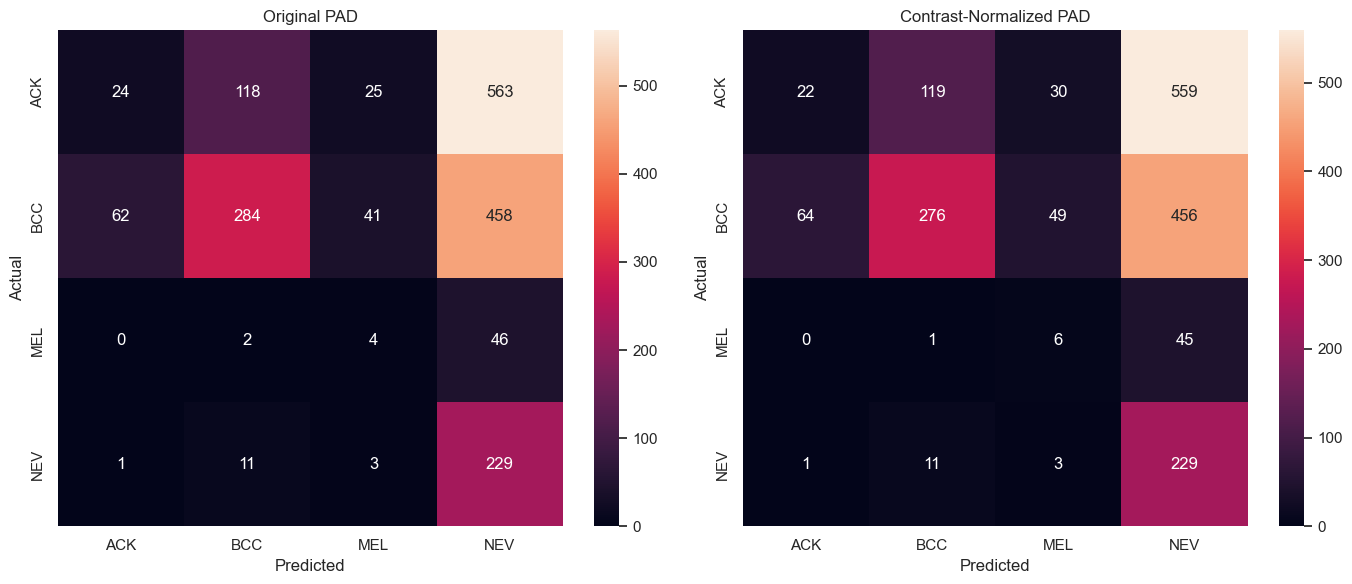

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    orig_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0]
)
axes[0].set_title("Original PAD")

sns.heatmap(
    norm_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1]
)
axes[1].set_title("Contrast-Normalized PAD")

for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
results_dict = {
    "source_dataset_mean_contrast": ham_mean_contrast,
    "target_dataset_mean_contrast": pad_mean_contrast,
    "contrast_factor": contrast_factor,
    "original_pad": {
        "accuracy": float(orig_acc_m),
        "precision": float(orig_prec),
        "recall": float(orig_rec),
        "f1": float(orig_f1),
        "auc": float(orig_auc)
    },
    "contrast_normalized_pad": {
        "accuracy": float(norm_acc_m),
        "precision": float(norm_prec),
        "recall": float(norm_rec),
        "f1": float(norm_f1),
        "auc": float(norm_auc)
    }
}

with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results_dict, f, indent=2)

print("Saved results.json")

Saved results.json


In [19]:
pad_norm[["img_id", "label", "image_path"]].to_csv(
    OUT_DIR / "contrast_normalized_pad_paths.csv",
    index=False
)

print("Saved normalized image path mapping.")

Saved normalized image path mapping.


In [20]:
print("\n--- CONTRAST NORMALIZATION REPORT ---")
print(f"HAM mean contrast: {ham_mean_contrast:.2f}")
print(f"PAD mean contrast: {pad_mean_contrast:.2f}")
print(f"Contrast factor: {contrast_factor:.4f}")
print(f"Original PAD F1: {orig_f1:.4f}")
print(f"Contrast-Normalized PAD F1: {norm_f1:.4f}")
print(f"F1 gain: {norm_f1 - orig_f1:.4f}")
print(f"Original PAD AUC: {orig_auc:.4f}")
print(f"Contrast-Normalized PAD AUC: {norm_auc:.4f}")


--- CONTRAST NORMALIZATION REPORT ---
HAM mean contrast: 28.43
PAD mean contrast: 25.27
Contrast factor: 1.1250
Original PAD F1: 0.2177
Contrast-Normalized PAD F1: 0.2198
F1 gain: 0.0021
Original PAD AUC: 0.6664
Contrast-Normalized PAD AUC: 0.6643
